# Mod6L5 Data Challenge — Interpreting SLR Output (Dec 2023 NYC Taxi)


**Format:** We Do (Instructor prompts) → You Do (Student work) → We Share (reflection)


**Goal:** Choose **one** dependent variable (**Y**) from the taxi dataset and build **three** simple linear regressions (each with a different single **X**) on **Dec 2023** rides. For each model, interpret the **coefficient**, **intercept**, **p‑value**, and **R‑squared** in plain business language. Then decide which model is “better” *for decision‑making* and why.


> **Reminder:** No train/test split or advanced metrics today. We focus on reading `.summary()` and communicating results.

## Instructor Section (10 mins)

**Follow these steps/considerations as you work**


1) **Pick a useful Y.** Which outcome would someone actually act on?  Who is the stakeholder for your Y?

*Avoid constructing Y that bakes in your X (e.g., avoid using `fare_amount` as X when Y = `total_amount` which already includes fare).*


2) **Choose three X’s** you can know at decision time, and that plausibly relate to Y. 

*You may engineer a feature to use in the model if you like*

*Note:  SLR needs numeric only inputs so variables like `PULocationID` can't be used (categorical → not for SLR today unless you transform; stick to numeric X for this exercise)*


3) **Interpretation lenses:**
- **Units:** Always state slope in units (e.g., “per mile”, “per minute”).
- **p‑value:** Does evidence suggest the slope ≠ 0?
- **R²:** How much of Y’s variation is captured by this X? Does that help the decision?
- **Intercept:** Is X=0 meaningful? If not, say it’s a math anchor.
- **Plausibility:** Does the direction/size make sense (e.g., longer trip → higher fare)?


4) **Better ≠ only higher R².** Weigh **interpretability**, **actionability**, and **evidence** (p‑value, CI) alongside R².

## YOU DO (40 mins)

### Step 1: Read in the Data & Choose your **Y** (dependent variable)

Pick one from the 2023_Yellow_Taxi_Trip_Data_20251015 csv file  

In [1]:
# import packages
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
import pandas as pd
import numpy as np

In [2]:
# Read in data and look at it!

df = pd.read_csv("/Users/kabbo/Downloads/2023_Yellow_Taxi_Trip_Data_20251015.csv", low_memory=False)
display(df.head())
display(df.info())
display(df.describe())

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,12/01/2023 04:11:39 PM,12/01/2023 04:19:13 PM,2.0,0.69,1.0,N,141,140,1,7.9,2.5,0.5,3,0.0,1.0,17.4,2.5,0.0
1,1,12/01/2023 04:11:39 PM,12/01/2023 04:20:41 PM,3.0,1.1,1.0,N,236,263,2,10,5.0,0.5,0,0.0,1.0,16.5,2.5,0.0
2,2,12/01/2023 04:11:39 PM,12/01/2023 04:20:38 PM,1.0,1.57,1.0,N,48,239,4,-10.7,-2.5,-0.5,0,0.0,-1.0,-17.2,-2.5,0.0
3,2,12/01/2023 04:11:39 PM,12/01/2023 04:20:38 PM,1.0,1.57,1.0,N,48,239,4,10.7,2.5,0.5,0,0.0,1.0,17.2,2.5,0.0
4,1,12/01/2023 04:11:39 PM,12/01/2023 04:34:39 PM,2.0,3,1.0,N,164,211,1,21.9,5.0,0.5,3,0.0,1.0,31.4,2.5,0.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3310907 entries, 0 to 3310906
Data columns (total 19 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   VendorID               int64  
 1   tpep_pickup_datetime   object 
 2   tpep_dropoff_datetime  object 
 3   passenger_count        float64
 4   trip_distance          object 
 5   RatecodeID             float64
 6   store_and_fwd_flag     object 
 7   PULocationID           int64  
 8   DOLocationID           int64  
 9   payment_type           int64  
 10  fare_amount            object 
 11  extra                  float64
 12  mta_tax                float64
 13  tip_amount             object 
 14  tolls_amount           float64
 15  improvement_surcharge  float64
 16  total_amount           object 
 17  congestion_surcharge   float64
 18  airport_fee            float64
dtypes: float64(8), int64(4), object(7)
memory usage: 479.9+ MB


None

,VendorID,passenger_count,RatecodeID,PULocationID,DOLocationID,payment_type,extra,mta_tax,tolls_amount,improvement_surcharge,congestion_surcharge,airport_fee
count,3.310907e+06,3.133527e+06,3.133527e+06,3.310907e+06,3.310907e+06,3.310907e+06,3.310907e+06,3.310907e+06,3.310907e+06,3.310907e+06,3.133527e+06,3.133527e+06
mean,1.750368e+00,1.409560e+00,1.784972e+00,1.650685e+02,1.639182e+02,1.168633e+00,1.485240e+00,4.828656e-01,5.734011e-01,9.758456e-01,2.270032e+00,1.367974e-01
std,4.356449e-01,9.117169e-01,8.283274e+00,6.428330e+01,6.968454e+01,5.959677e-01,1.814139e+00,1.206643e-01,2.228458e+00,2.170912e-01,8.078364e-01,4.796868e-01
min,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,-3.917000e+01,-5.000000e-01,-7.000000e+01,-1.000000e+00,-2.500000e+00,-1.750000e+00
25%,1.000000e+00,1.000000e+00,1.000000e+00,1.320000e+02,1.130000e+02,1.000000e+00,0.000000e+00,5.000000e-01,0.000000e+00,1.000000e+00,2.500000e+00,0.000000e+00
50%,2.000000e+00,1.000000e+00,1.000000e+00,1.620000e+02,1.620000e+02,1.000000e+00,1.000000e+00,5.000000e-01,0.000000e+00,1.000000e+00,2.500000e+00,0.000000e+00
75%,2.000000e+00,2.000000e+00,1.000000e+00,2.340000e+02,2.340000e+02,1.000000e+00,2.500000e+00,5.000000e-01,0.000000e+00,1.000000e+00,2.500000e+00,0.000000e+00
max,6.000000e+00,9.000000e+00,9.900000e+01,2.650000e+02,2.650000e+02,4.000000e+00,5.168000e+01,4.217000e+01,1.613800e+02,1.000000e+00,2.500000e+00,1.750000e+00


For the Y Dependent Variable, I chose fare_amount. The idea is that I want to see the relationship between fare_amount and Locations and Vendors. The stakeholder for Y would be a service like TLC who would be interested in knowing how fare amounts vary depending on pick up and drop off location and the vendor id.

### Step 2: Propose three candidate **X** predictors (numeric)

Pick three different X columns that are **numeric** and **known at decision time**.

The three X columns I chose are:
1) PULocationID
2) DOLocationID
3) VendorID 

### Step 3: Fit three one‑variable models with the SAME Y and different Xs

In [6]:
import statsmodels.api as sm


# 1. Convert 'fare_amount' to a numeric type.

df['fare_amount'] = pd.to_numeric(df['fare_amount'], errors='coerce')

# 2. OLS can't handle NaN values, so we must drop rows
#    where our variables of interest (fare_amount or PULocationID) are now NaN.
df_cleaned = df.dropna(subset=['fare_amount', 'PULocationID'])

x = sm.add_constant(df_cleaned[['PULocationID']])  # independent variable(s)
y = df_cleaned['fare_amount']                     # dependent variable

model = sm.OLS(y, x).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            fare_amount   R-squared:                       0.012
Model:                            OLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                 4.042e+04
Date:                Tue, 28 Oct 2025   Prob (F-statistic):               0.00
Time:                        20:21:21   Log-Likelihood:            -1.4402e+07
No. Observations:             3310903   AIC:                         2.880e+07
Df Residuals:                 3310901   BIC:                         2.880e+07
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           24.9628      0.028    879.403   

In [11]:
import statsmodels.api as sm


# 1. Convert 'fare_amount' to a numeric type.

df['fare_amount'] = pd.to_numeric(df['fare_amount'], errors='coerce')

# 2. OLS can't handle NaN values, so we must drop rows
df_cleaned = df.dropna(subset=['fare_amount', 'DOLocationID'])

x = sm.add_constant(df_cleaned[['DOLocationID']])  # independent variable(s)
y = df_cleaned['fare_amount']                     # dependent variable

model = sm.OLS(y, x).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            fare_amount   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                 2.518e+04
Date:                Tue, 28 Oct 2025   Prob (F-statistic):               0.00
Time:                        20:26:06   Log-Likelihood:            -1.4409e+07
No. Observations:             3310903   AIC:                         2.882e+07
Df Residuals:                 3310901   BIC:                         2.882e+07
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           23.4985      0.026    890.448   

In [12]:
import statsmodels.api as sm


# 1. Convert 'fare_amount' to a numeric type.

df['fare_amount'] = pd.to_numeric(df['fare_amount'], errors='coerce')

# 2. OLS can't handle NaN values, so we must drop rows
#    where our variables of interest (fare_amount or PULocationID) are now NaN.
df_cleaned = df.dropna(subset=['fare_amount', 'VendorID'])

x = sm.add_constant(df_cleaned[['VendorID']])  # independent variable(s)
y = df_cleaned['fare_amount']                     # dependent variable

model = sm.OLS(y, x).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            fare_amount   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     2088.
Date:                Tue, 28 Oct 2025   Prob (F-statistic):               0.00
Time:                        20:26:22   Log-Likelihood:            -1.4421e+07
No. Observations:             3310903   AIC:                         2.884e+07
Df Residuals:                 3310901   BIC:                         2.884e+07
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         17.7425      0.043    413.611      0.0

### Step 4: Visual check for the “best” model candidate

Pick the model you currently prefer (based on business sense + evidence).
- Create a scatter of X vs. Y with the fitted line.

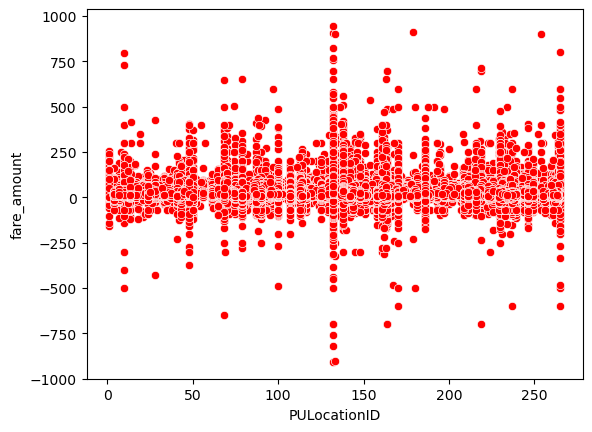

In [8]:
#X = PULocationID

import matplotlib.pyplot as plt 
import seaborn as sns   
fig = plt.figure()
sns.scatterplot(data=df, x='PULocationID', y='fare_amount', color='red')
plt.show()

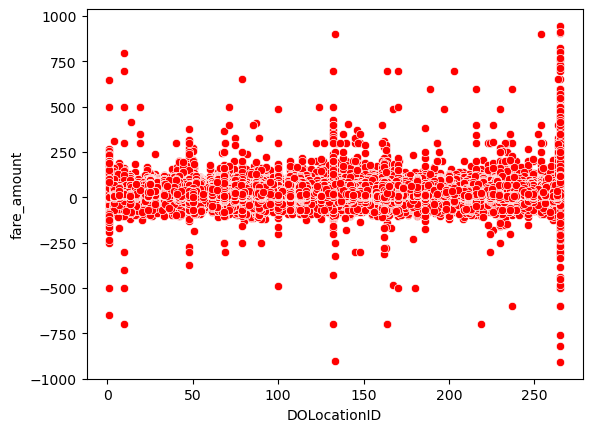

In [9]:
#X = DOLocationID

import matplotlib.pyplot as plt 
import seaborn as sns   
fig = plt.figure()
sns.scatterplot(data=df, x='DOLocationID', y='fare_amount', color='red')
plt.show()

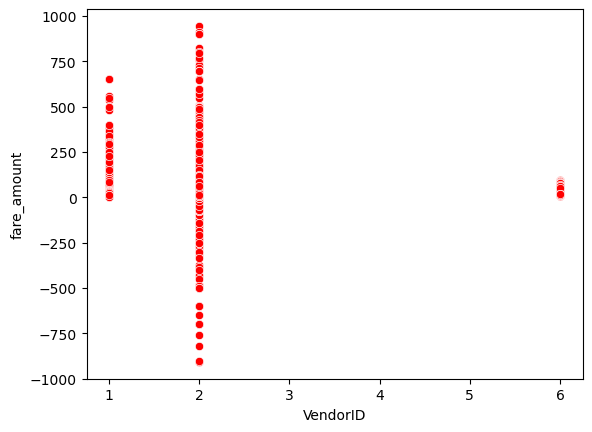

In [10]:
#X = VendorID

import matplotlib.pyplot as plt 
import seaborn as sns   
fig = plt.figure()
sns.scatterplot(data=df, x='VendorID', y='fare_amount', color='red')
plt.show()

### Step 5: Interpret Each Model (write in plain English)
Fill the three blocks below. Use **units** and **percentage points (pp)** where relevant.

- **Slope (β₁):** “For each +1 unit of X, Y changes by …”
- **Intercept (β₀):** meaningful or just a math anchor? Explain.
- **p‑value:** is there evidence the slope ≠ 0?
- **R²:** how much variation does this X explain?
- **Judgment:** is the effect size **practically** meaningful (tie to business)?

### Model A — Y = fare_amount ~ X1 = PULocation_ID
- Slope (β₁): For each +1 increase in the PULocationID number, the fare_amount is expected to decrease by $0.0322 (or about 3.2 cents), on average
- Intercept (β₀): The model predicts an average fare of $24.96 for a PULocationID of 0. Since '0' is not a real location ID, this intercept is just a mathematical anchor for the line and has no real-world business meaning.
- p‑value (slope): The p-value is 0.000, which is much smaller than 0.05. This means there is strong statistical evidence that the slope is not zero and that PULocationID has a statistically significant relationship with fare_amount.
- 95% CI for slope: 95% probability between -0.033 &  -0.032
- R²: The $R^2$ is 0.012. This is extremely low. It means that the PULocationID explains only 1.2% of the variation in fare_amount. The other 98.8% is explained by other factors (like trip distance, time, etc.).
- Business readout (units): The effect is not practically meaningful. While statistically significant (due to the huge dataset), the $R^2$ of 1.2% tells us this model has almost no predictive power. A 3-cent change per ID number is useless for any business decision.
- One limitation: The biggest limitation is that PULocationID is a categorical variable (a label for a zone), not a numeric one. Treating it as a number is a flaw in the model, as it assumes PULocationID 2 is "one unit more" than PULocationID 1, which is meaningless.

### Model B — Y = fare_amount ~ X2 = DOLocation_ID
- Slope (β₁): For each +1 increase in the DOLocationID number, the fare_amount is expected to decrease by $0.0235 (or about 2.4 cents), on average.
- Intercept (β₀): The model predicts an average fare of $23.50 for a DOLocationID of 0. Like the pickup ID, this is just a mathematical anchor and has no practical business meaning.
- p‑value (slope): The p-value of 0.000 provides strong statistical evidence that the slope is not zero and a statistically significant relationship exists.
- 95% CI for slope: 95% probability between -0.024 &  -0.023
- R²: The $R^2$ is 0.008. This is even worse than the first model. DOLocationID explains only 0.8% (less than 1%) of the variation in fare_amount.
- Business readout (units): This model is not practically meaningful. The $R^2$ is near-zero, meaning knowing the dropoff ID tells you nothing useful about the fare. This model should not be used for business decisions.
- One limitation: This model has the same limitation as the first: DOLocationID is a categorical variable (a place label) being incorrectly treated as a continuous number.

### Model C — Y = {{YOUR_Y}} ~ X3 = {{YOUR_X3}}
- Slope (β₁): The VendorID is either 1 or 2. This slope means that, on average, trips using Vendor 2 are $1.09 more expensive than trips using Vendor 1.
- Intercept (β₀): The model predicts a fare of $17.74 for a VendorID of 0. Since 0 is not a valid vendor, this is just a mathematical anchor. (The model predicts Vendor 1's average fare would be $17.74 + $1.09 = $18.83$)
- p‑value (slope): The p-value of 0.000 provides strong statistical evidence that there is a real difference in the average fare between Vendor 1 and Vendor 2.
- 95% CI for slope: 95% probability between 1.040 & 1.133
- R²: The $R^2$ is 0.001. This means VendorID explains only 0.1% of the variation in fare_amount. This is virtually zero.
- Business readout (units): This is not practically meaningful. Although a $1.09 difference is statistically 'real', the $R^2$ of 0.1% tells us that knowing the vendor gives you no real predictive power over the fare. The fare is dictated by distance and time, not the vendor's payment system.
- One limitation: VendorID is a categorical variable with only two values. 

## We Share (10 mins) — Reflection & Decision (write 1-2 short paragraphs)

1) **Which model is “better” for a stakeholder decision and why?**
- Weigh **evidence** (p‑value, CI), **explanatory power** (R²), **interpretability**, and **business impact** (units, MDE if relevant).

        The VendorID model is the only one that provides a legitimate, interpretable, and potentially actionable insight for a stakeholder, even though it has no predictive power. A stakeholder could ask, "Why are Vendor 2's trips more expensive? Are they adding a fee?" The other two models are simply statistically unusable.
2) **What would you do next week to strengthen trust in this model?**
- (Preview) time‑based validation, hold‑out testing, segment checks, adding more plausible X’s, checking assumptions.

        I suppose learning better models and knowing how to identify which columns to choose. I would also like to validate my assumptions before engaging in a statistical test.